# Exploración de Datos — Predicción del Precio de Vivienda
**Problema de Regresión: Valor de la Vivienda**  
Grupo 4 — Modelos Estadísticos

## 0. Instalación e importación de librerías

In [1]:
paquetes <- c("tidyverse", "ggplot2", "corrplot", "moments",
              "gridExtra", "scales", "knitr", "reshape2", "GGally")

nuevos <- paquetes[!(paquetes %in% installed.packages()[, "Package"])]
if (length(nuevos) > 0) install.packages(nuevos, quiet = TRUE)

# Cargar librerías
library(tidyverse)
library(ggplot2)
library(corrplot)
library(moments)    # skewness y kurtosis
library(gridExtra)
library(scales)
library(knitr)
library(reshape2)
library(GGally)

# Opciones globales
options(scipen = 999, digits = 3)
cat("Librerías cargadas correctamente\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Adjuntando el paquete: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine



Adjuntando el paquete: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Adjuntando el paquete: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




Librerías cargadas correctamente


## 1. Exploración inicial y estructura de datos

In [2]:
# Carga directa
df <- read.csv("../data/raw/Train real state.csv", stringsAsFactors = TRUE)

# Eliminar columna índice si existe
df$X <- NULL

cat("Dimensiones del dataset:", nrow(df), "filas x", ncol(df), "columnas\n")
head(df)

Dimensiones del dataset: 4124 filas x 30 columnas


,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.,N_SchoolNearBy.High.,N_SchoolNearBy.University.,N_FacilitiesInApt,N_FacilitiesNearBy.Total.,N_SchoolNearBy.Total.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,141592,2006,2007,8,814,3,terraced,individual_heating,management_in_trust,111,⋯,1,1,0,3,2,2,2,5,6,9
2,51327,1985,2007,8,587,8,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
3,48672,1985,2007,8,587,6,corridor,individual_heating,self_management,80,⋯,1,2,1,2,1,1,0,3,12,4
4,221238,1993,2007,8,1761,3,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17
5,78318,1992,2007,8,644,2,mixed,individual_heating,self_management,142,⋯,1,1,0,3,3,4,4,3,9,14
6,61946,1993,2007,8,644,10,mixed,individual_heating,management_in_trust,523,⋯,1,5,0,4,3,5,5,4,14,17


In [3]:
# Tipos de datos y estructura general
cat("=== ESTRUCTURA DEL DATASET ===\n")
str(df)

=== ESTRUCTURA DEL DATASET ===
'data.frame':	4124 obs. of  30 variables:
 $ SalePrice                         : int  141592 51327 48672 221238 78318 61946 83185 168141 153982 200884 ...
 $ YearBuilt                         : int  2006 1985 1985 1993 1992 1993 1992 1986 1986 2007 ...
 $ YrSold                            : int  2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...
 $ MonthSold                         : int  8 8 8 8 8 8 8 8 8 8 ...
 $ Size.sqf.                         : int  814 587 587 1761 644 644 644 1377 914 868 ...
 $ Floor                             : int  3 8 6 3 2 10 13 4 11 18 ...
 $ HallwayType                       : Factor w/ 3 levels "corridor","mixed",..: 3 1 1 2 2 2 2 3 3 3 ...
 $ HeatingType                       : Factor w/ 2 levels "central_heating",..: 2 2 2 2 2 2 2 1 1 2 ...
 $ AptManageType                     : Factor w/ 2 levels "management_in_trust",..: 1 2 2 1 2 1 2 1 1 1 ...
 $ N_Parkinglot.Ground.              : int  111 80 80 523 142 523 142 7

In [4]:
# Identificar columnas categóricas y numéricas
cat_cols <- names(df)[sapply(df, is.factor)]
num_cols <- names(df)[sapply(df, is.numeric)]

# Remover el índice ('Unnamed..0' o 'X') y la variable objetivo para no tratarla como un predictor
num_cols_feat <- num_cols[!num_cols %in% c("SalePrice")]

cat("\nVariables categóricas (", length(cat_cols), "):\n")
print(cat_cols)

cat("\nVariables numéricas sin target (", length(num_cols_feat), "):\n")
print(num_cols_feat)


Variables categóricas ( 6 ):
[1] "HallwayType"   "HeatingType"   "AptManageType" "TimeToBusStop"
[5] "TimeToSubway"  "SubwayStation"

Variables numéricas sin target ( 23 ):
 [1] "YearBuilt"                          "YrSold"                            
 [3] "MonthSold"                          "Size.sqf."                         
 [5] "Floor"                              "N_Parkinglot.Ground."              
 [7] "N_Parkinglot.Basement."             "N_APT"                             
 [9] "N_manager"                          "N_elevators"                       
[11] "N_FacilitiesNearBy.PublicOffice."   "N_FacilitiesNearBy.Hospital."      
[13] "N_FacilitiesNearBy.Dpartmentstore." "N_FacilitiesNearBy.Mall."          
[15] "N_FacilitiesNearBy.ETC."            "N_FacilitiesNearBy.Park."          
[17] "N_SchoolNearBy.Elementary."         "N_SchoolNearBy.Middle."            
[19] "N_SchoolNearBy.High."               "N_SchoolNearBy.University."        
[21] "N_FacilitiesInApt"            

## 2. Calidad y Limpieza de datos

In [5]:
# === Valores faltantes y duplicados ===
missing_df <- data.frame(
  Variable    = names(df),
  Faltantes   = colSums(is.na(df)),
  Porcentaje  = round(colSums(is.na(df)) / nrow(df) * 100, 2)
)

missing_df <- missing_df[missing_df$Faltantes > 0, ]
missing_df <- missing_df[order(-missing_df$Porcentaje), ]

if (nrow(missing_df) == 0) {
  cat("No hay valores faltantes en el dataset\n")
} else {
  print(missing_df)
}

# === DUPLICADOS ===
n_dup <- sum(duplicated(df))
cat("Filas duplicadas exactas:", n_dup, "\n")

No hay valores faltantes en el dataset
Filas duplicadas exactas: 192 


In [6]:
# Ver los grupos de duplicados, ordenados para comparar pares
dup_view <- df[duplicated(df) | duplicated(df, fromLast = TRUE), ]
dup_view <- dup_view[order(dup_view$SalePrice, dup_view$Size.sqf., dup_view$Floor), ]
head(dup_view[, c("SalePrice","YearBuilt","Size.sqf.","Floor","SubwayStation")], 20)

,SalePrice,YearBuilt,Size.sqf.,Floor,SubwayStation
,<int>,<int>,<int>,<int>,<fct>
719,61946,1992,576,11,Myung-duk
724,61946,1992,576,11,Myung-duk
873,73053,2005,572,6,Bangoge
926,73053,2005,572,6,Bangoge
938,73442,2005,572,9,Bangoge
944,73442,2005,572,9,Bangoge
856,73840,2005,572,11,Bangoge
908,73840,2005,572,11,Bangoge
842,73840,2005,572,12,Bangoge


In [7]:
# Eliminar duplicados exactos
df <- df[!duplicated(df), ]

cat("Dimensiones tras eliminar duplicados:", nrow(df), "filas x", ncol(df), "columnas\n")

Dimensiones tras eliminar duplicados: 3932 filas x 30 columnas


## 3. Estadísticas descriptivas, distribución y outliers - Variables numericas

In [8]:
# Estadisticas descriptivas para variables numéricas
vars_num <- df[, c(num_cols_feat, "SalePrice")]

tabla_desc <- data.frame(
  COLUMNA = names(vars_num),
  CONTEO  = sapply(vars_num, function(x) sum(!is.na(x))),
  MEDIA   = round(sapply(vars_num, mean,   na.rm = TRUE), 2),
  MEDIANA = round(sapply(vars_num, median, na.rm = TRUE), 2),
  STD     = round(sapply(vars_num, sd,     na.rm = TRUE), 2),
  MIN     = sapply(vars_num, min, na.rm = TRUE),
  Q25     = sapply(vars_num, quantile, probs = 0.25, na.rm = TRUE),
  Q50     = sapply(vars_num, quantile, probs = 0.50, na.rm = TRUE),
  Q75     = sapply(vars_num, quantile, probs = 0.75, na.rm = TRUE),
  MAX     = sapply(vars_num, max, na.rm = TRUE),
  stringsAsFactors = FALSE
)
rownames(tabla_desc) <- NULL

# Mostrar en el notebook
library(knitr)
kable(tabla_desc, col.names = c("COLUMNA","CONTEO","MEDIA","MEDIANA","STD",
                                "MIN","25%","50%","75%","MAX"))





|COLUMNA                            | CONTEO|     MEDIA| MEDIANA|       STD|   MIN|    25%|    50%|    75%|    MAX|
|:----------------------------------|------:|---------:|-------:|---------:|-----:|------:|------:|------:|------:|
|YearBuilt                          |   3932|   2002.65|    2006|      8.89|  1978|   1993|   2006|   2007|   2015|
|YrSold                             |   3932|   2012.68|    2013|      2.89|  2007|   2010|   2013|   2015|   2017|
|MonthSold                          |   3932|      6.30|       6|      3.35|     1|      3|      6|      9|     12|
|Size.sqf.                          |   3932|    969.61|     910|    377.88|   135|    644|    910|   1160|   2337|
|Floor                              |   3932|     12.15|      11|      7.69|     1|      6|     11|     17|     43|
|N_Parkinglot.Ground.               |   3932|    201.48|     111|    219.85|     0|     25|    111|    249|    713|
|N_Parkinglot.Basement.             |   3932|    559.41|     536|    4

No id variables; using all as measure variables



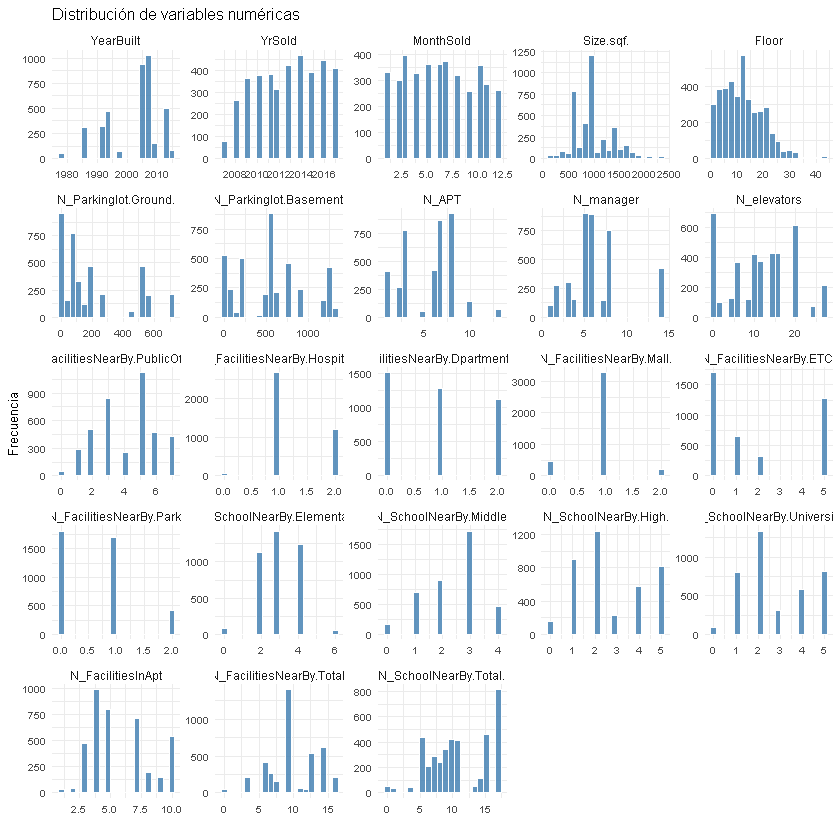

In [9]:
# Distribución de variables numéricas 
library(ggplot2)
library(reshape2)

# Convertir a formato largo para graficar todas juntas
df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(x = value)) +
  geom_histogram(bins = 20, fill = "steelblue", color = "white", alpha = 0.85) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Distribución de variables numéricas", x = "", y = "Frecuencia") +
  theme(strip.text = element_text(size = 7),
        axis.text = element_text(size = 6))
ggsave("distribucion_numericas.png", width = 14, height = 12, dpi = 150)

No id variables; using all as measure variables



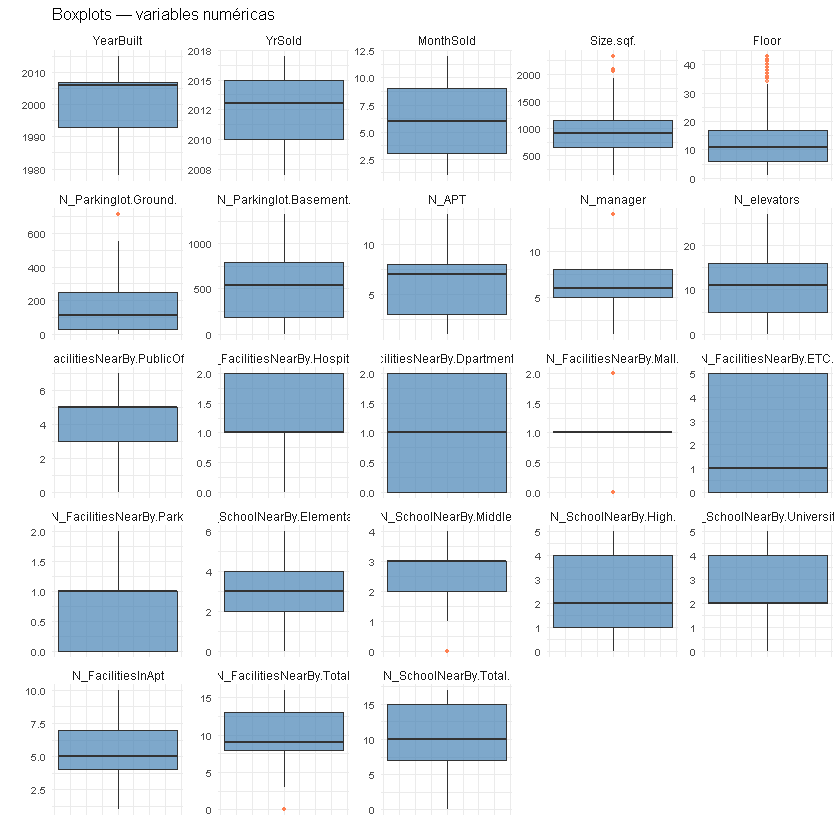

In [10]:
# Boxplots para detectar outliers
library(ggplot2)
library(reshape2)

df_long <- melt(df[, num_cols_feat])

ggplot(df_long, aes(y = value)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 0.8) +
  facet_wrap(~ variable, scales = "free", ncol = 5) +
  theme_minimal(base_size = 8) +
  labs(title = "Boxplots — variables numéricas", x = "", y = "") +
  theme(strip.text = element_text(size = 7),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        axis.text.y = element_text(size = 6))
ggsave("boxplots_numericas.png", width = 14, height = 12, dpi = 150)

## 4. Estadísticas descriptivas y frecuencia - Variables categoricas

In [11]:
# Estadísticas descriptivas para variables categóricas
tabla_cat <- data.frame(
  COLUMNA    = cat_cols,
  CONTEO     = sapply(cat_cols, function(c) sum(!is.na(df[[c]]))),
  CATEGORIAS = sapply(cat_cols, function(c) nlevels(df[[c]])),
  TOP        = sapply(cat_cols, function(c) names(which.max(table(df[[c]])))),
  FRECUENCIA = sapply(cat_cols, function(c) max(table(df[[c]]))),
  PORCENTAJE = sapply(cat_cols, function(c) round(max(table(df[[c]])) / sum(!is.na(df[[c]])) * 100, 2))
)
rownames(tabla_cat) <- NULL

library(knitr)
kable(tabla_cat, align = "lrrlrr",
      col.names = c("COLUMNA","CONTEO","CATEGORÍAS","TOP","FRECUENCIA","% TOP"))

write.csv2(tabla_cat, "estadisticas_categoricas.csv", row.names = FALSE)




|COLUMNA       | CONTEO| CATEGORÍAS|TOP                   | FRECUENCIA| % TOP|
|:-------------|------:|----------:|:---------------------|----------:|-----:|
|HallwayType   |   3932|          3|terraced              |       2380|  60.5|
|HeatingType   |   3932|          2|individual_heating    |       3720|  94.6|
|AptManageType |   3932|          2|management_in_trust   |       3684|  93.7|
|TimeToBusStop |   3932|          3|0~5min                |       2977|  75.7|
|TimeToSubway  |   3932|          5|0-5min                |       1830|  46.5|
|SubwayStation |   3932|          8|Kyungbuk_uni_hospital |       1072|  27.3|

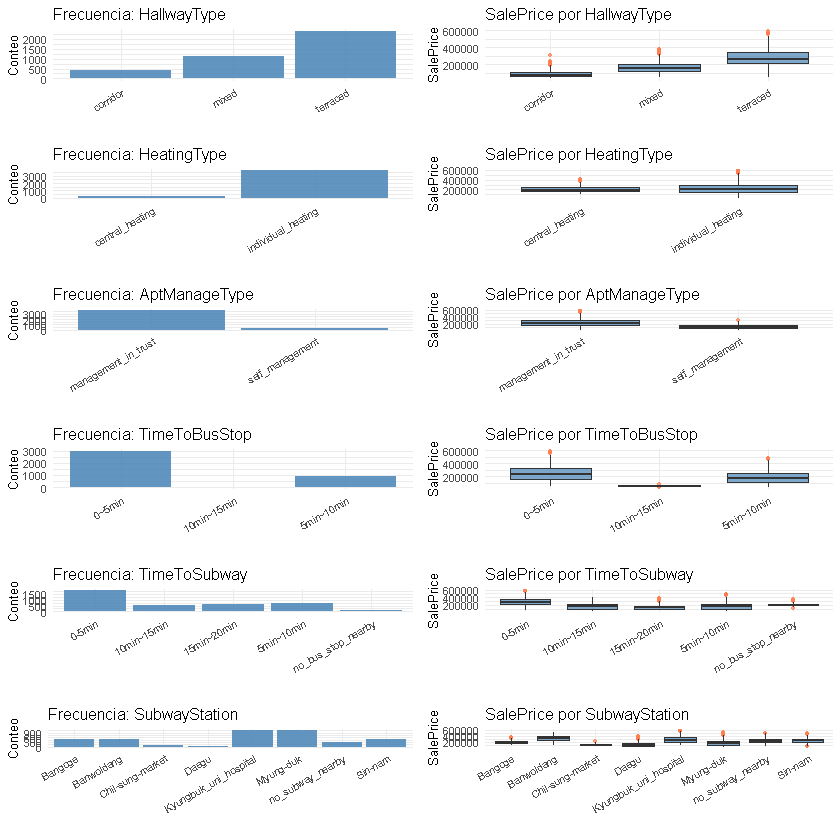

In [12]:
# Variables categóricas: frecuencia y boxplot de SalePrice
library(ggplot2)
library(gridExtra)

plots <- list()

for (col in cat_cols) {
  # Gráfico de frecuencia
  p1 <- ggplot(df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue", alpha = 0.85) +
    theme_minimal(base_size = 8) +
    labs(title = paste("Frecuencia:", col), x = "", y = "Conteo") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  # Boxplot SalePrice por categoría
  p2 <- ggplot(df, aes(x = .data[[col]], y = SalePrice)) +
    geom_boxplot(fill = "steelblue", alpha = 0.7,
                 outlier.color = "coral", outlier.size = 0.8) +
    theme_minimal(base_size = 8) +
    labs(title = paste("SalePrice por", col), x = "", y = "SalePrice") +
    theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 6))

  plots[[length(plots) + 1]] <- p1
  plots[[length(plots) + 1]] <- p2
}

# Organizar en grilla (2 columnas: frecuencia + boxplot por fila)
grid.arrange(grobs = plots, ncol = 2)

g <- arrangeGrob(grobs = plots, ncol = 2)
ggsave("categoricas_frecuencia.png", g, width = 12, height = 18, dpi = 150)

## 5. Análisis de la variable objetivo: SalePrice

Media:     225857 
Mediana:   212389 
Skewness:  0.439 
Kurtosis:  2.68 


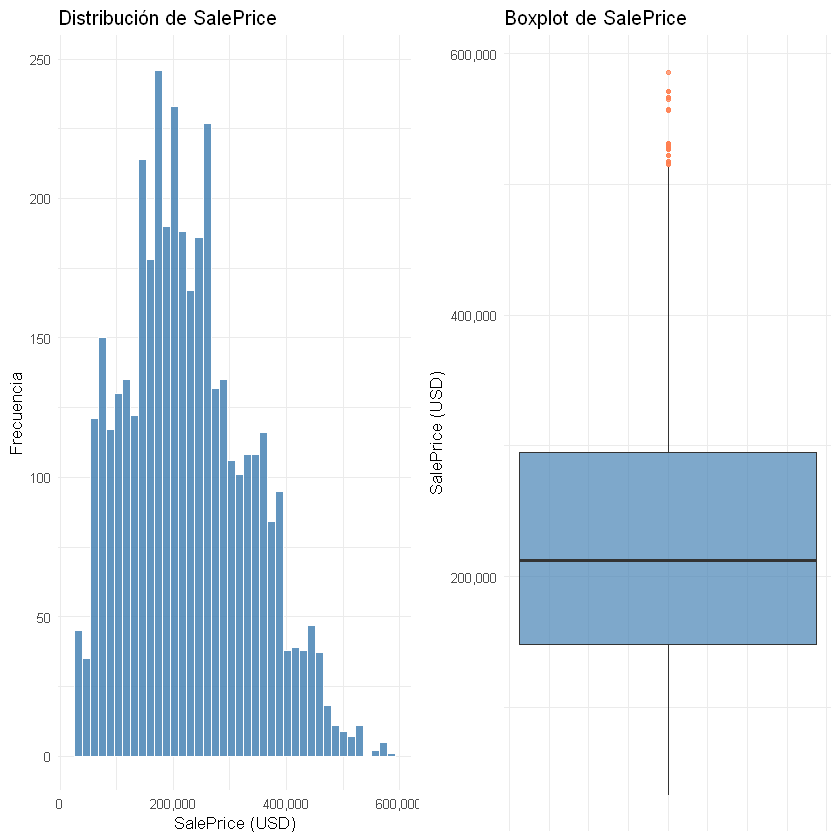

In [13]:
# === VARIABLE OBJETIVO: SALEPRICE ===
library(ggplot2)
library(gridExtra)
library(scales)

# Histograma
p1 <- ggplot(df, aes(x = SalePrice)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white", alpha = 0.85) +
  scale_x_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Distribución de SalePrice", x = "SalePrice (USD)", y = "Frecuencia")

# Boxplot
p2 <- ggplot(df, aes(y = SalePrice)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7,
               outlier.color = "coral", outlier.size = 1) +
  scale_y_continuous(labels = comma) +
  theme_minimal(base_size = 10) +
  labs(title = "Boxplot de SalePrice", y = "SalePrice (USD)") +
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank())

grid.arrange(p1, p2, ncol = 2)

# Estadísticas de forma
library(moments)
cat("Media:    ", round(mean(df$SalePrice), 2), "\n")
cat("Mediana:  ", round(median(df$SalePrice), 2), "\n")
cat("Skewness: ", round(skewness(df$SalePrice), 3), "\n")
cat("Kurtosis: ", round(kurtosis(df$SalePrice), 3), "\n")

g <- arrangeGrob(p1, p2, ncol = 2)
ggsave("variable_objetivo.png", g, width = 14, height = 5, dpi = 150)

## 6. Correlación entre variables numéricas

agg_record_5f2c16624b51 
                      2

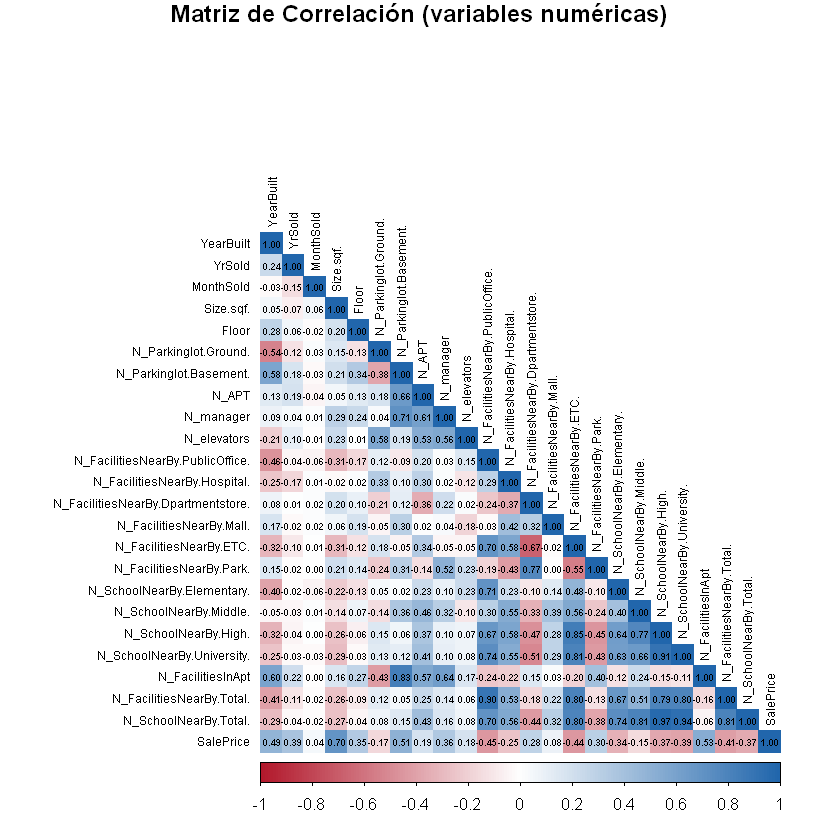

In [14]:
# === MATRIZ DE CORRELACIÓN (VARIABLES NUMÉRICAS) ===
library(corrplot)

# Calcular correlaciones (predictores + target)
corr_matrix <- cor(df[, c(num_cols_feat, "SalePrice")])

# Visualización
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         title = "Matriz de Correlación (variables numéricas)",
         mar = c(0,0,1,0))

png("matriz_correlacion.png", width = 1600, height = 1400, res = 130)
corrplot(corr_matrix, method = "color", type = "lower",
         tl.cex = 0.6, tl.col = "black",
         number.cex = 0.45, addCoef.col = "black",
         col = colorRampPalette(c("#B2182B", "white", "#2166AC"))(200),
         mar = c(0,0,1,0))
dev.off()

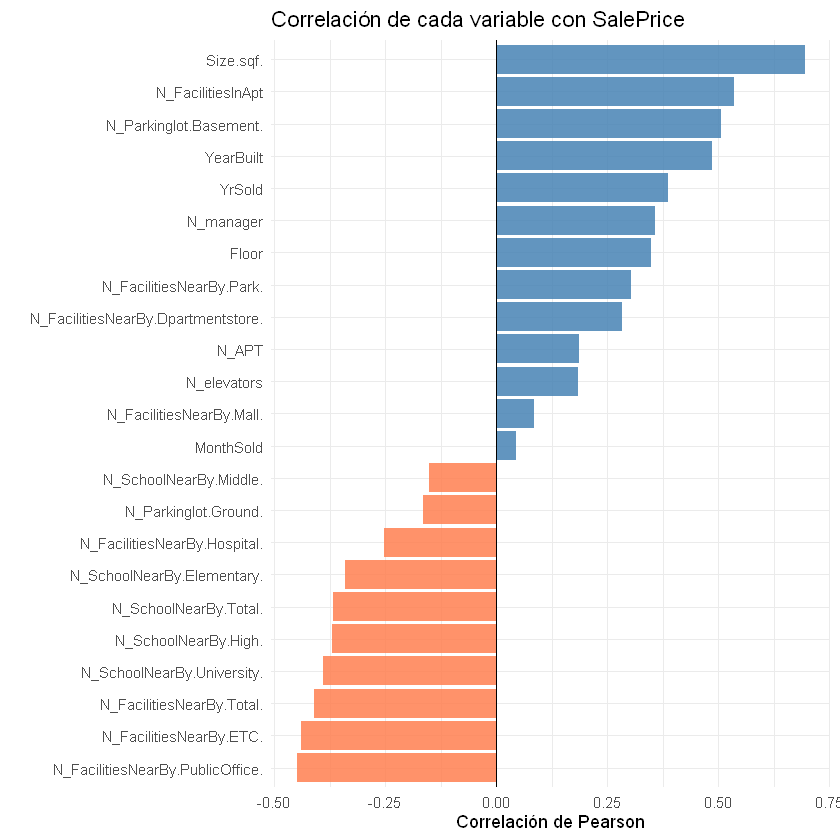

In [15]:
# Top correlaciones con SalePrice (ordenadas por valor absoluto)
corr_target <- corr_matrix["SalePrice", ]
corr_target <- corr_target[names(corr_target) != "SalePrice"]
corr_target <- sort(corr_target, decreasing = FALSE)  # ascendente para barh

corr_df <- data.frame(
  Variable    = names(corr_target),
  Correlacion = as.numeric(corr_target)
)
corr_df$Color <- ifelse(corr_df$Correlacion >= 0, "positiva", "negativa")

ggplot(corr_df, aes(x = Correlacion,
                    y = reorder(Variable, Correlacion),
                    fill = Color)) +
  geom_bar(stat = "identity", alpha = 0.85) +
  geom_vline(xintercept = 0, color = "black", linewidth = 0.5) +
  scale_fill_manual(values = c("positiva" = "steelblue",
                               "negativa" = "coral")) +
  labs(title = "Correlación de cada variable con SalePrice",
       x = "Correlación de Pearson", y = "") +
  theme_minimal() +
  theme(legend.position = "none")

## 7. Scatter plots — variables más correlacionadas con SalePrice

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


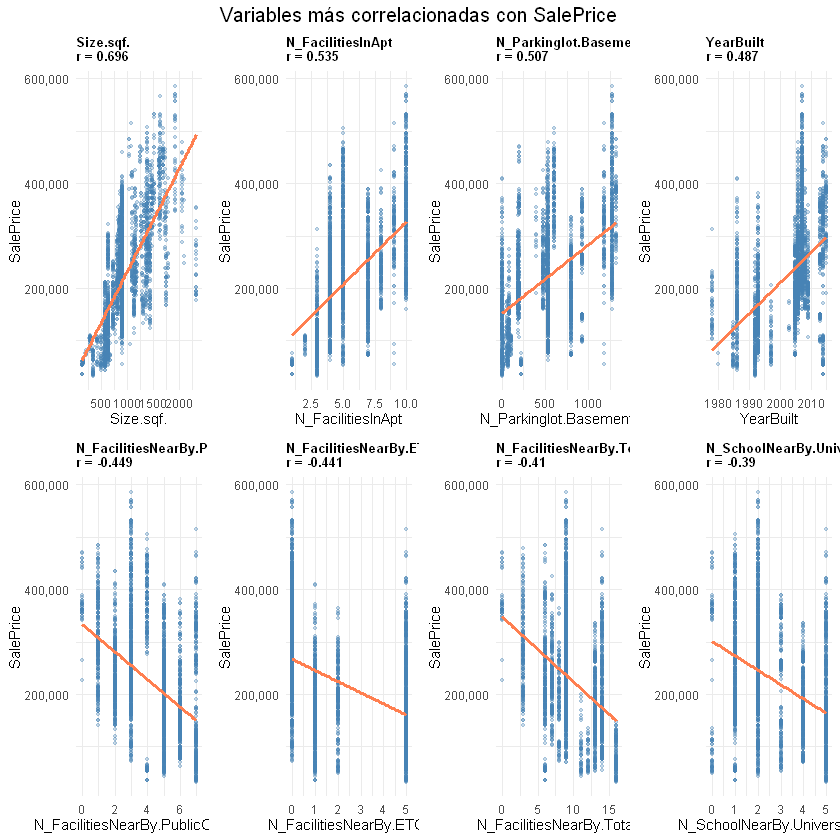

In [16]:
# Top 8 variables con mayor correlación absoluta
top8 <- names(sort(abs(corr_target), decreasing = TRUE))[1:8]

plots_scatter <- lapply(top8, function(col) {
  r_val <- round(cor(df[[col]], df$SalePrice, use = "complete.obs"), 3)
  ggplot(df, aes_string(x = col, y = "SalePrice")) +
    geom_point(alpha = 0.3, color = "steelblue", size = 0.8) +
    geom_smooth(method = "lm", se = FALSE, color = "coral", linewidth = 1) +
    scale_y_continuous(labels = comma) +
    labs(title = paste0(col, "\nr = ", r_val),
         x = col, y = "SalePrice") +
    theme_minimal(base_size = 9) +
    theme(plot.title = element_text(size = 8, face = "bold"))
})

do.call(grid.arrange, c(plots_scatter, ncol = 4,
  top = "Variables más correlacionadas con SalePrice"))

## 8. Resumen final de la exploración

In [17]:
cat(strrep("=", 60), "\n")
cat("         RESUMEN DE LA EXPLORACIÓN DE DATOS\n")
cat(strrep("=", 60), "\n")
cat(sprintf("  Observaciones:            %d\n",   nrow(df)))
cat(sprintf("  Variables totales:        %d\n",   ncol(df)))
cat(sprintf("  Variables numéricas:      %d\n",   length(num_cols_feat)))
cat(sprintf("  Variables categóricas:    %d\n",   length(cat_cols)))
cat(sprintf("  Columnas con nulos:       %d\n",   sum(colSums(is.na(df)) > 0)))
cat(sprintf("  SalePrice — Media:        $%s\n",  format(round(mean(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Mediana:      $%s\n",  format(median(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Std:          $%s\n",  format(round(sd(df$SalePrice), 0), big.mark=",")))
cat(sprintf("  SalePrice — Min:          $%s\n",  format(min(df$SalePrice), big.mark=",")))
cat(sprintf("  SalePrice — Max:          $%s\n",  format(max(df$SalePrice), big.mark=",")))
cat(sprintf("  Asimetría SalePrice:      %.4f\n", skewness(df$SalePrice)))
cat("\n  Top 5 correlaciones con SalePrice:\n")
top5_corr <- sort(abs(corr_target), decreasing = TRUE)[1:5]
for (nm in names(top5_corr)) {
  cat(sprintf("    %-35s r = %.4f\n", nm, corr_matrix["SalePrice", nm]))
}
cat(strrep("=", 60), "\n")

         RESUMEN DE LA EXPLORACIÓN DE DATOS
  Observaciones:            3932
  Variables totales:        30
  Variables numéricas:      23
  Variables categóricas:    6
  Columnas con nulos:       0
  SalePrice — Media:        $225,857
  SalePrice — Mediana:      $212,389
  SalePrice — Std:          $106,273
  SalePrice — Min:          $32,743
  SalePrice — Max:          $585,840
  Asimetría SalePrice:      0.4391

  Top 5 correlaciones con SalePrice:
    Size.sqf.                           r = 0.6955
    N_FacilitiesInApt                   r = 0.5349
    N_Parkinglot.Basement.              r = 0.5065
    YearBuilt                           r = 0.4870
    N_FacilitiesNearBy.PublicOffice.    r = -0.4494


# Modelo — Predicción del Precio de Vivienda
**Modelo de regresión lineal**
**Problema de Regresión: Valor de la Vivienda**  

## 0. Preparación de datos

In [18]:
library(dplyr)

# Cargar train y test
train <- read.csv("../data/raw/Train real state.csv", stringsAsFactors = TRUE)
test  <- read.csv("../data/raw/Test real state.csv",  stringsAsFactors = TRUE)

# La primera columna sin nombre llega como "X":
# en train es un índice desechable, en test es el Id que exige Kaggle
test_ids <- test$X
train$X <- NULL
test$X  <- NULL

# Alinear niveles de factores del test a los de train (evita errores en predict)
cat_cols <- c("HallwayType","HeatingType","AptManageType",
              "TimeToBusStop","TimeToSubway","SubwayStation")
for (c in cat_cols)
  test[[c]] <- factor(as.character(test[[c]]), levels = levels(train[[c]]))

# Quitar duplicados exactos SOLO en train
train <- train[!duplicated(train), ]

cat("train:", nrow(train), "x", ncol(train), "\n")
cat("test :", nrow(test), "x", ncol(test), " | n Ids:", length(test_ids), "\n")

train: 3932 x 30 
test : 1767 x 29  | n Ids: 1767 


## 1. Selección de variables — colinealidad y redundancia

In [19]:
# 1a. Verificar si los "totales" son la suma exacta de sus componentes
fac_comp <- c("N_FacilitiesNearBy.PublicOffice.","N_FacilitiesNearBy.Hospital.",
              "N_FacilitiesNearBy.Dpartmentstore.","N_FacilitiesNearBy.Mall.",
              "N_FacilitiesNearBy.ETC.","N_FacilitiesNearBy.Park.")
sch_comp <- c("N_SchoolNearBy.Elementary.","N_SchoolNearBy.Middle.",
              "N_SchoolNearBy.High.","N_SchoolNearBy.University.")

es_suma_facilities <- all(train$N_FacilitiesNearBy.Total. == rowSums(train[fac_comp]))
es_suma_schools     <- all(train$N_SchoolNearBy.Total.     == rowSums(train[sch_comp]))

cat("N_FacilitiesNearBy.Total. es la suma exacta de sus componentes:", es_suma_facilities, "\n")
cat("N_SchoolNearBy.Total. es la suma exacta de sus componentes:    ", es_suma_schools, "\n")

N_FacilitiesNearBy.Total. es la suma exacta de sus componentes: TRUE 
N_SchoolNearBy.Total. es la suma exacta de sus componentes:     TRUE 


In [20]:
install.packages("car")

Installing package into 'C:/Users/USER/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'car' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\USER\AppData\Local\Temp\RtmpsVI8nQ\downloaded_packages


In [21]:
# 1b. Confirmar formalmente con VIF: ajustamos un modelo CON los totales
# y mostramos que produce VIF infinito (colinealidad perfecta)
library(car)

modelo_con_totales <- lm(SalePrice ~ ., data = train)
vif(modelo_con_totales)

Warning message:
"package 'car' was built under R version 4.6.1"
Cargando paquete requerido: carData

Warning message:
"package 'carData' was built under R version 4.6.1"

Adjuntando el paquete: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some




ERROR: Error in vif.default(modelo_con_totales): there are aliased coefficients in the model


In [ ]:
alias(modelo_con_totales)

Model :
SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + SubwayStation + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle. + N_SchoolNearBy.High. + 
    N_SchoolNearBy.University. + N_FacilitiesInApt + N_FacilitiesNearBy.Total. + 
    N_SchoolNearBy.Total.

Complete :
                                   (Intercept)           YearBuilt            
SubwayStationSin-nam                                   1                     0
N_FacilitiesNearBy.Dpartmentstore.           -7805/15886                     0
N_FacilitiesNearBy.Mall.                    -22993/43856                     0
N_FacilitiesNearBy.ETC.    

In [ ]:
# Modelo sin los 2 totales y sin SubwayStation (su información ya está
# capturada por TimeToSubway + los conteos de facilidades/colegios)
totales <- c("N_FacilitiesNearBy.Total.", "N_SchoolNearBy.Total.")

train_m <- train %>% select(-all_of(totales), -SubwayStation)

modelo_base <- lm(SalePrice ~ ., data = train_m)
vif(modelo_base)

ERROR: Error in vif.default(modelo_base): there are aliased coefficients in the model


In [ ]:
alias(modelo_base)

Model :
SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle. + N_SchoolNearBy.High. + 
    N_SchoolNearBy.University. + N_FacilitiesInApt

Complete :
                           (Intercept)          YearBuilt           
N_SchoolNearBy.High.               -68649/82571                    0
N_SchoolNearBy.University.      -3716610/657223                    0
N_FacilitiesInApt              -10180691/198513                    0
                           YrSold               MonthSold           
N_SchoolNearBy.High.                          0                    0
N_

In [ ]:
# Quitar también las 3 variables que resultaron aliased (combinación lineal exacta
# de las demás, probablemente por redundancia entre colegios cercanos y ubicación)
train_m <- train_m %>% select(-N_SchoolNearBy.High., -N_SchoolNearBy.University., -N_FacilitiesInApt)

modelo_base <- lm(SalePrice ~ ., data = train_m)
vif(modelo_base)

,GVIF,Df,GVIF^(1/(2*Df))
YearBuilt,8.610106e+01,1,9.279065
YrSold,1.324678e+00,1,1.150947
MonthSold,1.061314e+00,1,1.030201
Size.sqf.,2.050712e+00,1,1.432031
Floor,1.222213e+00,1,1.105537
HallwayType,8.650191e+05,2,30.496951
HeatingType,3.943196e+03,1,62.794874
AptManageType,8.981264e+01,1,9.476953
N_Parkinglot.Ground.,2.974459e+04,1,172.466203
N_Parkinglot.Basement.,3.070451e+05,1,554.116546


In [ ]:
library(MASS)

# Selección stepwise bidireccional por AIC, partiendo del modelo completo (sin aliasing)
modelo_step <- stepAIC(modelo_base, direction = "both", trace = FALSE)

# Ver qué variables sobrevivieron
summary(modelo_step)


Adjuntando el paquete: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
lm(formula = SalePrice ~ YearBuilt + YrSold + MonthSold + Size.sqf. + 
    Floor + HallwayType + HeatingType + AptManageType + N_Parkinglot.Ground. + 
    N_Parkinglot.Basement. + TimeToBusStop + TimeToSubway + N_APT + 
    N_manager + N_elevators + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Dpartmentstore. + 
    N_FacilitiesNearBy.Mall. + N_FacilitiesNearBy.ETC. + N_FacilitiesNearBy.Park. + 
    N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle., data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-152788  -17312     625   19153  164122 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        -3.170e+07  9.306e+05 -34.067   <2e-16 ***
YearBuilt                           5.053e+03  5.778e+02   8.745   <2e-16 ***
YrSold                              1.283e+04  2.203e+02  58.231   <2e-16 ***
MonthSold                           1.763e+03  1.701e+0

In [ ]:
# Verificar colinealidad del modelo ya seleccionado
vif(modelo_step)

,GVIF,Df,GVIF^(1/(2*Df))
YearBuilt,8.610106e+01,1,9.279065
YrSold,1.324678e+00,1,1.150947
MonthSold,1.061314e+00,1,1.030201
Size.sqf.,2.050712e+00,1,1.432031
Floor,1.222213e+00,1,1.105537
HallwayType,8.650191e+05,2,30.496951
HeatingType,3.943196e+03,1,62.794874
AptManageType,8.981264e+01,1,9.476953
N_Parkinglot.Ground.,2.974459e+04,1,172.466203
N_Parkinglot.Basement.,3.070451e+05,1,554.116546


In [ ]:
# Eliminación iterativa por VIF: en cada paso quita la variable más colineal
# y recalcula, hasta que todo quede por debajo del umbral
vif_step <- function(model, threshold = 10) {
  repeat {
    v <- vif(model)
    if (is.matrix(v)) {
      # Para factores, VIF equivalente = GVIF^(1/(2*Df))^2
      vals <- v[, 3]^2
      names(vals) <- rownames(v)
    } else {
      vals <- v
    }
    max_val <- max(vals)
    if (max_val < threshold) break
    remove_var <- names(vals)[which.max(vals)]
    cat("Eliminando:", remove_var, "  (VIF =", round(max_val, 1), ")\n")
    model <- update(model, as.formula(paste(". ~ . -", remove_var)))
  }
  model
}

modelo_vif <- vif_step(modelo_base, threshold = 10)

Eliminando: N_Parkinglot.Basement.   (VIF = 307045.1 )
Eliminando: N_manager   (VIF = 368.5 )
Eliminando: N_elevators   (VIF = 155 )
Eliminando: N_FacilitiesNearBy.Dpartmentstore.   (VIF = 56.7 )
Eliminando: HeatingType   (VIF = 24.7 )
Eliminando: N_FacilitiesNearBy.ETC.   (VIF = 17.6 )
Eliminando: YearBuilt   (VIF = 13.8 )


In [ ]:
summary(modelo_vif)
vif(modelo_vif)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_FacilitiesNearBy.Mall. + 
    N_FacilitiesNearBy.Park. + N_SchoolNearBy.Elementary. + N_SchoolNearBy.Middle., 
    data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-218679  -20051    1569   23728  160398 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -2.605e+07  4.780e+05 -54.491  < 2e-16 ***
YrSold                            1.298e+04  2.373e+02  54.684  < 2e-16 ***
MonthSold                         2.140e+03  1.877e+02  11.401  < 2e-16 ***
Size.sqf.                         1.510e+02  2.146e+00  70.351  < 2e-16 ***
Floor                             1.370e+03  8.837e+01  15.501  < 2e-16 ***
HallwayTypemixed                 -2.533e+04  5.512e+03  

,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.238448,1,1.112856
MonthSold,1.040711,1,1.020152
Size.sqf.,1.728187,1,1.314605
Floor,1.212705,1,1.101229
HallwayType,70.991699,2,2.902698
AptManageType,1.956067,1,1.398595
N_Parkinglot.Ground.,4.284982,1,2.070020
TimeToBusStop,5.491341,2,1.530804
TimeToSubway,319.686304,4,2.056319
N_APT,4.065694,1,2.016357


In [ ]:
# Prueba F parcial: ¿aportan las variables no significativas, en conjunto?
modelo_reducido <- update(modelo_vif, . ~ . - N_FacilitiesNearBy.Mall. 
                                          - N_FacilitiesNearBy.Park. 
                                          - N_SchoolNearBy.Middle.)

anova(modelo_reducido, modelo_vif)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3913,5.851293e+12,NA,NA,NA,NA
2,3910,5.847857e+12,3,3436462629,0.7658971,0.5130364


In [ ]:
summary(modelo_reducido)
vif(modelo_reducido)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary., 
    data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-217711  -20201    1609   23332  160377 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -2.615e+07  4.719e+05 -55.421  < 2e-16 ***
YrSold                            1.303e+04  2.344e+02  55.583  < 2e-16 ***
MonthSold                         2.134e+03  1.874e+02  11.386  < 2e-16 ***
Size.sqf.                         1.507e+02  2.117e+00  71.183  < 2e-16 ***
Floor                             1.355e+03  8.685e+01  15.599  < 2e-16 ***
HallwayTypemixed                 -2.421e+04  4.478e+03  -5.407 6.79e-08 ***
HallwayTypeterraced               6.360e+04  3.642e+03  17.463  

,GVIF,Df,GVIF^(1/(2*Df))
YrSold,1.208365,1,1.099256
MonthSold,1.037784,1,1.018717
Size.sqf.,1.681977,1,1.296911
Floor,1.171611,1,1.082410
HallwayType,33.107329,2,2.398728
AptManageType,1.764126,1,1.328204
N_Parkinglot.Ground.,3.493138,1,1.868994
TimeToBusStop,2.981793,2,1.314073
TimeToSubway,63.404355,4,1.679828
N_APT,2.289290,1,1.513040


## 2. Estructura del modelo

In [ ]:
modelo_base <- modelo_reducido   # este es nuestro modelo de trabajo desde ahora

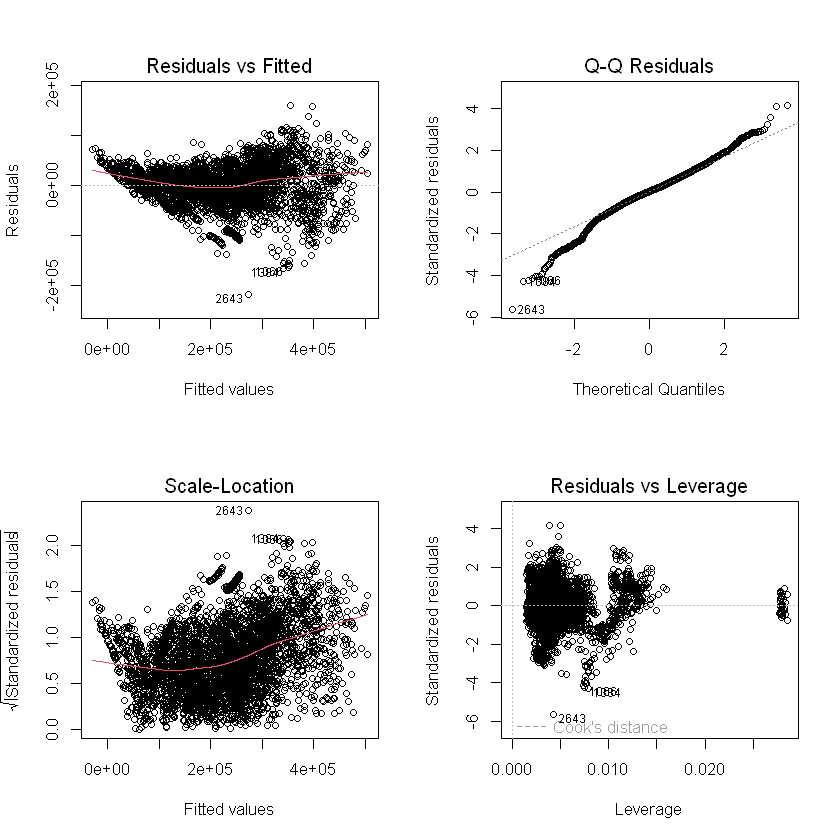

In [ ]:
par(mfrow = c(2, 2))
plot(modelo_base)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


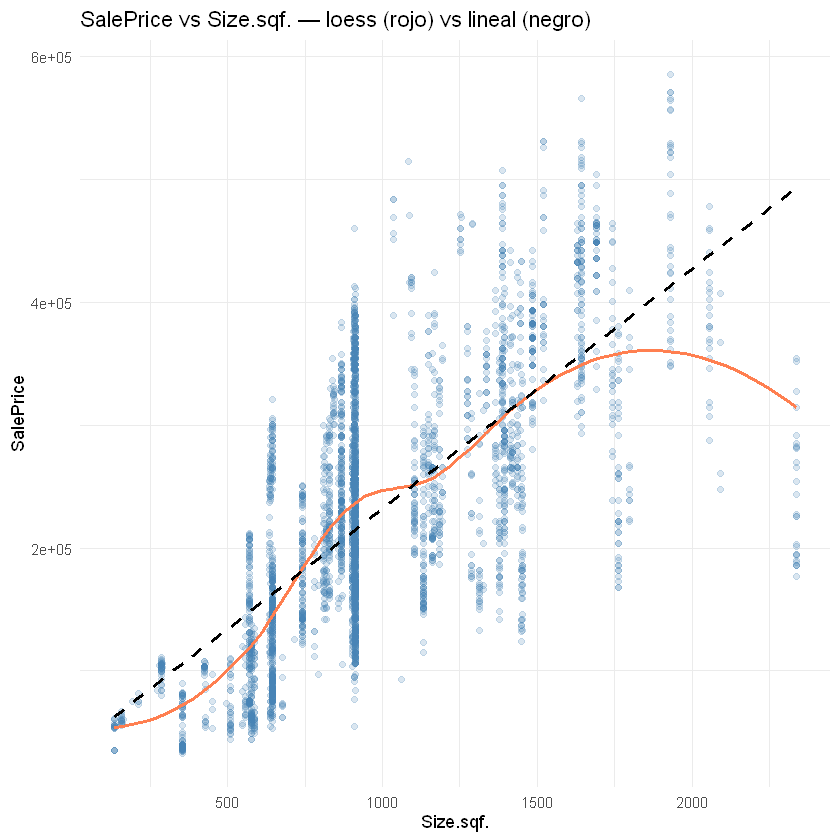

In [ ]:
# Relación Size.sqf. vs SalePrice con curva suavizada (detectar curvatura)
library(ggplot2)
ggplot(train_m, aes(x = Size.sqf., y = SalePrice)) +
  geom_point(alpha = 0.2, color = "steelblue") +
  geom_smooth(method = "loess", color = "coral", se = FALSE) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  theme_minimal() +
  labs(title = "SalePrice vs Size.sqf. — loess (rojo) vs lineal (negro)")

In [ ]:
# Inspeccionar la observación más influyente en los residuos
train_m[2643, ]

,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_manager,N_elevators,N_FacilitiesNearBy.PublicOffice.,N_FacilitiesNearBy.Hospital.,N_FacilitiesNearBy.Dpartmentstore.,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
2736,308849,2007,2014,11,868,26,terraced,individual_heating,management_in_trust,0,⋯,14,16,3,1,2,1,0,2,3,3


In [ ]:
# Ver también las otras dos que se repiten en los diagnósticos
train_m[c(864, 1086), ]

,SalePrice,YearBuilt,YrSold,MonthSold,Size.sqf.,Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot.Ground.,⋯,N_manager,N_elevators,N_FacilitiesNearBy.PublicOffice.,N_FacilitiesNearBy.Hospital.,N_FacilitiesNearBy.Dpartmentstore.,N_FacilitiesNearBy.Mall.,N_FacilitiesNearBy.ETC.,N_FacilitiesNearBy.Park.,N_SchoolNearBy.Elementary.,N_SchoolNearBy.Middle.
,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
941,141592,2005,2010,5,743,19,mixed,individual_heating,management_in_trust,67,⋯,6,0,5,2,0,1,5,0,3,4
1170,206194,2007,2010,12,868,12,terraced,individual_heating,management_in_trust,0,⋯,14,16,3,1,2,1,0,2,3,3


In [ ]:
# Probar estructura: agregar curvatura en Size.sqf.
modelo_cuad <- update(modelo_base, . ~ . + I(Size.sqf.^2))
summary(modelo_cuad)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2), data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222323  -22060    -380   22320  193906 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -2.709e+07  4.383e+05 -61.812  < 2e-16 ***
YrSold                            1.346e+04  2.176e+02  61.834  < 2e-16 ***
MonthSold                         1.938e+03  1.736e+02  11.163  < 2e-16 ***
Size.sqf.                         3.845e+02  9.338e+00  41.176  < 2e-16 ***
Floor                             1.293e+03  8.042e+01  16.075  < 2e-16 ***
HallwayTypemixed                 -5.962e+04  4.369e+03 -13.647  < 2e-16 ***
HallwayTypeterraced               2.627e+04  3.

In [ ]:
# Interacción: ¿el efecto de Size.sqf. depende del tipo de pasillo?
modelo_inter <- update(modelo_cuad, . ~ . + Size.sqf.:HallwayType)
summary(modelo_inter)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222535  -19705     644   20796  171778 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -2.769e+07  4.202e+05 -65.892  < 2e-16 ***
YrSold                            1.375e+04  2.087e+02  65.903  < 2e-16 ***
MonthSold                         1.777e+03  1.662e+02  10.692  < 2e-16 ***
Size.sqf.                         3.442e+02  1.166e+01  29.518  < 2e-16 ***
Floor                             1.201e+03  7.716e+01  15.560  < 2e-16 ***
HallwayTypemixed                 -5.783e+04  7.953e+03  -7.271 4.28e-13 ***
HallwayTypeterraced    

In [ ]:
# Comparar formalmente los 3 modelos anidados con prueba F
anova(modelo_base, modelo_cuad, modelo_inter)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3913,5.851293e+12,NA,NA,NA,NA
2,3912,5.011130e+12,1,840163698936,718.0647,2.288397e-145
3,3910,4.574852e+12,2,436277092303,186.4370,4.603185e-78


In [ ]:
# Verificar formalmente las observaciones influyentes con Cook's distance
cooks <- cooks.distance(modelo_inter)
umbral <- 4 / nrow(train_m)
influyentes <- which(cooks > umbral)
cat("N° de observaciones influyentes (Cook's D > 4/n):", length(influyentes), "de", nrow(train_m), "\n")
cat("Las 5 más influyentes:\n")
print(sort(cooks, decreasing = TRUE)[1:5])

N° de observaciones influyentes (Cook's D > 4/n): 206 de 3932 
Las 5 más influyentes:
        331        2643         105        3016        4124 
0.008990081 0.008376177 0.007839822 0.007661801 0.006999994 


## 3. Estimación de los parametros del modelo

In [ ]:
modelo_final <- modelo_inter   # este es el modelo definitivo desde ahora

## 4. Verificación de los supuestos del modelo

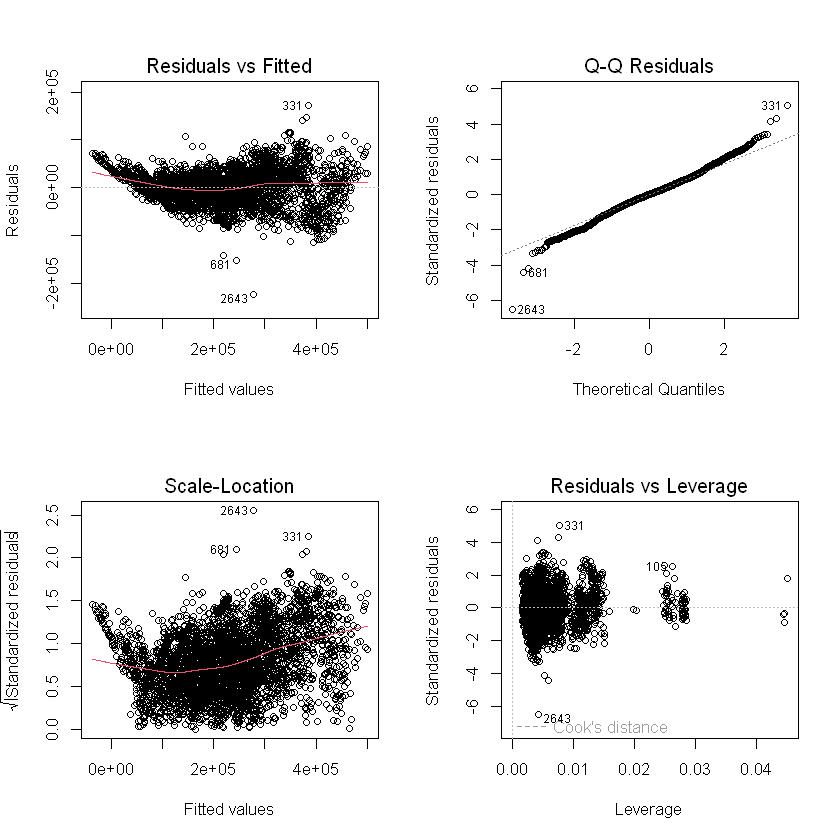

In [ ]:
par(mfrow = c(2, 2))
plot(modelo_final)

In [ ]:
library(lmtest)

# 1. Linealidad + homocedasticidad: Breusch-Pagan
bptest(modelo_final)

Warning message:
"package 'lmtest' was built under R version 4.6.1"
Cargando paquete requerido: zoo

Warning message:
"package 'zoo' was built under R version 4.6.1"

Adjuntando el paquete: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo_final
BP = 669.13, df = 21, p-value < 2.2e-16


In [ ]:
# 2. Normalidad de los residuos (Shapiro sobre una muestra, ya que n>5000 lo satura)
set.seed(42)
muestra <- sample(residuals(modelo_final), 5000)
shapiro.test(muestra)

ERROR: Error in sample.int(length(x), size, replace, prob): imposible tomar una muestra mayor que la población cuando 'replace = FALSE'


In [ ]:
# 3. Independencia de los residuos (Durbin-Watson)
dwtest(modelo_final)


	Durbin-Watson test

data:  modelo_final
DW = 1.091, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


In [ ]:
# Normalidad: usamos todos los residuos directamente (n=3932 < límite de 5000 de shapiro.test)
shapiro.test(residuals(modelo_final))


	Shapiro-Wilk normality test

data:  residuals(modelo_final)
W = 0.99142, p-value = 1.158e-14


In [ ]:
# ¿El DW detecta estructura por edificio/ubicación en vez de autocorrelación temporal real?
# Ordenamos por N_APT y N_Parkinglot.Ground. (proxies de "mismo edificio") y repetimos
train_ordenado <- train_m[order(train_m$N_APT, train_m$N_Parkinglot.Ground.), ]
modelo_ordenado <- lm(formula(modelo_final), data = train_ordenado)
dwtest(modelo_ordenado)


	Durbin-Watson test

data:  modelo_ordenado
DW = 0.68325, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


## 5. Determinación de la bondad de ajuste del modelo

In [ ]:
# Bondad de ajuste: resumen consolidado
cat("R²          :", round(summary(modelo_final)$r.squared, 4), "\n")
cat("R² ajustado  :", round(summary(modelo_final)$adj.r.squared, 4), "\n")
cat("AIC          :", round(AIC(modelo_final)), "\n")
cat("BIC          :", round(BIC(modelo_final)), "\n")
cat("Error estándar residual:", round(summary(modelo_final)$sigma), "\n")
cat("Estadístico F:", round(summary(modelo_final)$fstatistic[1], 1),
    " en (", summary(modelo_final)$fstatistic[2], ",", summary(modelo_final)$fstatistic[3], ") gl\n")

R²          : 0.897 
R² ajustado  : 0.8964 
AIC          : 93284 
BIC          : 93428 
Error estándar residual: 34206 
Estadístico F: 1620.7  en ( 21 , 3910 ) gl


## 6. Calculo de intervalos de confianza para los parametros del modelo

In [ ]:
# Intervalos de confianza al 95% para los coeficientes
confint(modelo_final, level = 0.95)

,2.5 %,97.5 %
(Intercept),-2.850894e+07,-2.686143e+07
YrSold,1.334279e+04,1.416101e+04
MonthSold,1.451017e+03,2.102625e+03
Size.sqf.,3.213800e+02,3.671089e+02
Floor,1.049390e+03,1.351958e+03
HallwayTypemixed,-7.341899e+04,-4.223518e+04
HallwayTypeterraced,-5.243672e+04,-2.035595e+04
AptManageTypeself_management,-6.650031e+04,-5.310375e+04
N_Parkinglot.Ground.,-1.506972e+02,-1.322309e+02
TimeToBusStop10min~15min,-5.270270e+04,-1.977980e+04


## 7. Prueba de hipótesis sobre los parámetros del modelo

In [ ]:
# H0: los coeficientes de TimeToSubway son conjuntamente 0 (el factor completo no aporta)
modelo_sin_subway <- update(modelo_final, . ~ . - TimeToSubway)
anova(modelo_sin_subway, modelo_final)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3914,5.076162e+12,NA,NA,NA,NA
2,3910,4.574852e+12,4,501309855621,107.1139,1.007567e-86


In [ ]:
# Pruebas t individuales por coeficiente (H0: β_i = 0)
# Ya se mostraron en la sección de estructura del modelo; se referencian aquí
# como evidencia principal de las pruebas de hipótesis a nivel individual.
summary(modelo_final)


Call:
lm(formula = SalePrice ~ YrSold + MonthSold + Size.sqf. + Floor + 
    HallwayType + AptManageType + N_Parkinglot.Ground. + TimeToBusStop + 
    TimeToSubway + N_APT + N_FacilitiesNearBy.PublicOffice. + 
    N_FacilitiesNearBy.Hospital. + N_SchoolNearBy.Elementary. + 
    I(Size.sqf.^2) + Size.sqf.:HallwayType, data = train_m)

Residuals:
    Min      1Q  Median      3Q     Max 
-222535  -19705     644   20796  171778 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      -2.769e+07  4.202e+05 -65.892  < 2e-16 ***
YrSold                            1.375e+04  2.087e+02  65.903  < 2e-16 ***
MonthSold                         1.777e+03  1.662e+02  10.692  < 2e-16 ***
Size.sqf.                         3.442e+02  1.166e+01  29.518  < 2e-16 ***
Floor                             1.201e+03  7.716e+01  15.560  < 2e-16 ***
HallwayTypemixed                 -5.783e+04  7.953e+03  -7.271 4.28e-13 ***
HallwayTypeterraced    

## 8. Interpretación de los coeficientes del modelo

**Variables numéricas** (interpretación directa: "por cada unidad adicional,
manteniendo todo lo demás constante"):

- **YrSold** (β=13.750, IC 95%: [13.343, 14.161]): cada año adicional de venta
  se asocia con un incremento de ~$13.750 en el precio, reflejando apreciación
  general del mercado a lo largo del tiempo.
- **MonthSold** (β=1.777): efecto estacional leve, ~$1.777 más por cada mes de
  avance dentro del año.
- **Floor** (β=1.201): cada piso adicional añade ~$1.201 al precio, controlando
  por lo demás.
- **N_Parkinglot.Ground.** (β=-141.5): cada parqueadero de superficie adicional
  se asocia con una **reducción** de ~$141.5 — contraintuitivo a primera vista,
  pero probablemente refleja que más parqueaderos de superficie (vs.
  subterráneos) indica un desarrollo más antiguo o de menor categoría.
- **N_APT** (β=4.691): cada apartamento adicional en el conjunto suma ~$4.691,
  asociado a mayor escala/infraestructura del complejo.
- **N_FacilitiesNearBy.PublicOffice.** (β=3.315) y **N_FacilitiesNearBy.Hospital.**
  (β=10.650): más oficinas públicas y hospitales cercanos se asocian
  positivamente con el precio (proximidad a servicios).
- **N_SchoolNearBy.Elementary.** (β=-22.810): signo negativo — más colegios
  primarios cercanos se asocia con *menor* precio, posiblemente porque estas
  zonas corresponden a áreas residenciales más antiguas o periféricas.

**Variable con curvatura — Size.sqf. y Size.sqf.²:**

Al incluir tanto el término lineal (β=344.2) como el cuadrático (β=-0.098), el
efecto marginal del tamaño no es constante; la relación presenta rendimientos
decrecientes:

$$\frac{\partial SalePrice}{\partial Size.sqf.} = 344.2 + 2\times(-0.098)\times Size.sqf.$$

Por ejemplo, a 500 sqf el efecto marginal es ≈ $246/sqf adicional, mientras que
a 1500 sqf cae a ≈ $50/sqf — coherente con el patrón observado en el gráfico
de dispersión (loess) de la sección de estructura del modelo.

**Interacción Size.sqf.:HallwayType:**

El efecto del tamaño depende del tipo de pasillo:
- `corridor` (base): pendiente de referencia (344.2)
- `terraced`: pendiente adicional de +79.63 → el tamaño premia *más* el precio
  en edificios tipo terraced
- `mixed`: +7.31, no significativo (p=0.53) → no difiere de `corridor`

**Variables categóricas** (respecto a categoría base):

- **AptManageTypeself_management** (β=-59.800): apartamentos con autogestión
  valen ~$59.800 menos que los de gestión fiduciaria (`management_in_trust`),
  sugiriendo que una administración profesional se asocia con mayor valor.
- **TimeToSubway**: patrón no monotónico (`15min~20min` con el mayor efecto
  relativo, +$67.390) — probablemente refleja que ciertas distancias
  coinciden con zonas específicas de mayor valor, más que un efecto puro de
  distancia. Se documenta como hallazgo asociativo, no causal.

## 9.  Predicción sobre el conjunto de prueba y generación del submission

In [ ]:
# Predicción sobre el conjunto de test
pred_test <- predict(modelo_final, newdata = test)

# Sanity check: comparar rango de predicciones vs rango real de SalePrice en train
cat("Rango predicciones test:", round(min(pred_test)), "-", round(max(pred_test)), "\n")
cat("Rango SalePrice train  :", min(train$SalePrice), "-", max(train$SalePrice), "\n")
cat("N° de predicciones negativas o absurdas (<0):", sum(pred_test < 0), "\n")

Rango predicciones test: -36155 - 483447 
Rango SalePrice train  : 32743 - 585840 
N° de predicciones negativas o absurdas (<0): 16 


In [ ]:
# Truncar negativos al mínimo observado en train (blindaje ante extrapolación
# multivariada del término cuadrático) y armar el submission en el formato
# exacto que exige Kaggle: Id, Predicted
pred_test <- pmax(pred_test, min(train$SalePrice))
submission <- data.frame(Id = test_ids, Predicted = round(pred_test))

write.csv(submission, "submission_grupo4.csv", row.names = FALSE)
cat("Filas en submission:", nrow(submission), "\n")
head(submission)

Filas en submission: 1767 


,Id,Predicted
,<int>,<dbl>
1,3016,265450
2,5492,261013
3,2757,107079
4,1397,218128
5,510,73344
6,4985,419884
